In [1]:
#%pip install factor_analyzer semopy xgboost nltk


1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.


Cargado exitosamente desde: ../../../data/junaeb2n.csv


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,...,41854.000000,41854.000000,41854.000000,41854.000000,41854.000000,40419.000000,41854.000000,41303.000000,41854.000000,41854.000000
mean,0.552325,83.066039,1.014083,0.720051,0.965141,1.117958,1.397310,1.270129,1.263129,1.275935,...,1.346920,1.887275,1.397620,1.511158,1.715941,2.552611,0.911621,12.975280,12.897142,0.083457
std,0.497261,3.987135,1.380418,0.449830,0.192328,0.401019,0.661753,0.594456,0.588868,0.575344,...,0.682243,0.959059,0.684203,0.811187,1.002515,1.069379,0.283848,3.373766,3.462212,0.943453
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,81.000000,0.100000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,11.000000,11.000000,-1.000000
50%,1.000000,82.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,84.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area        41854 non-null  int64  


None

Dimensiones del dataset tras limpieza: (39898, 25)


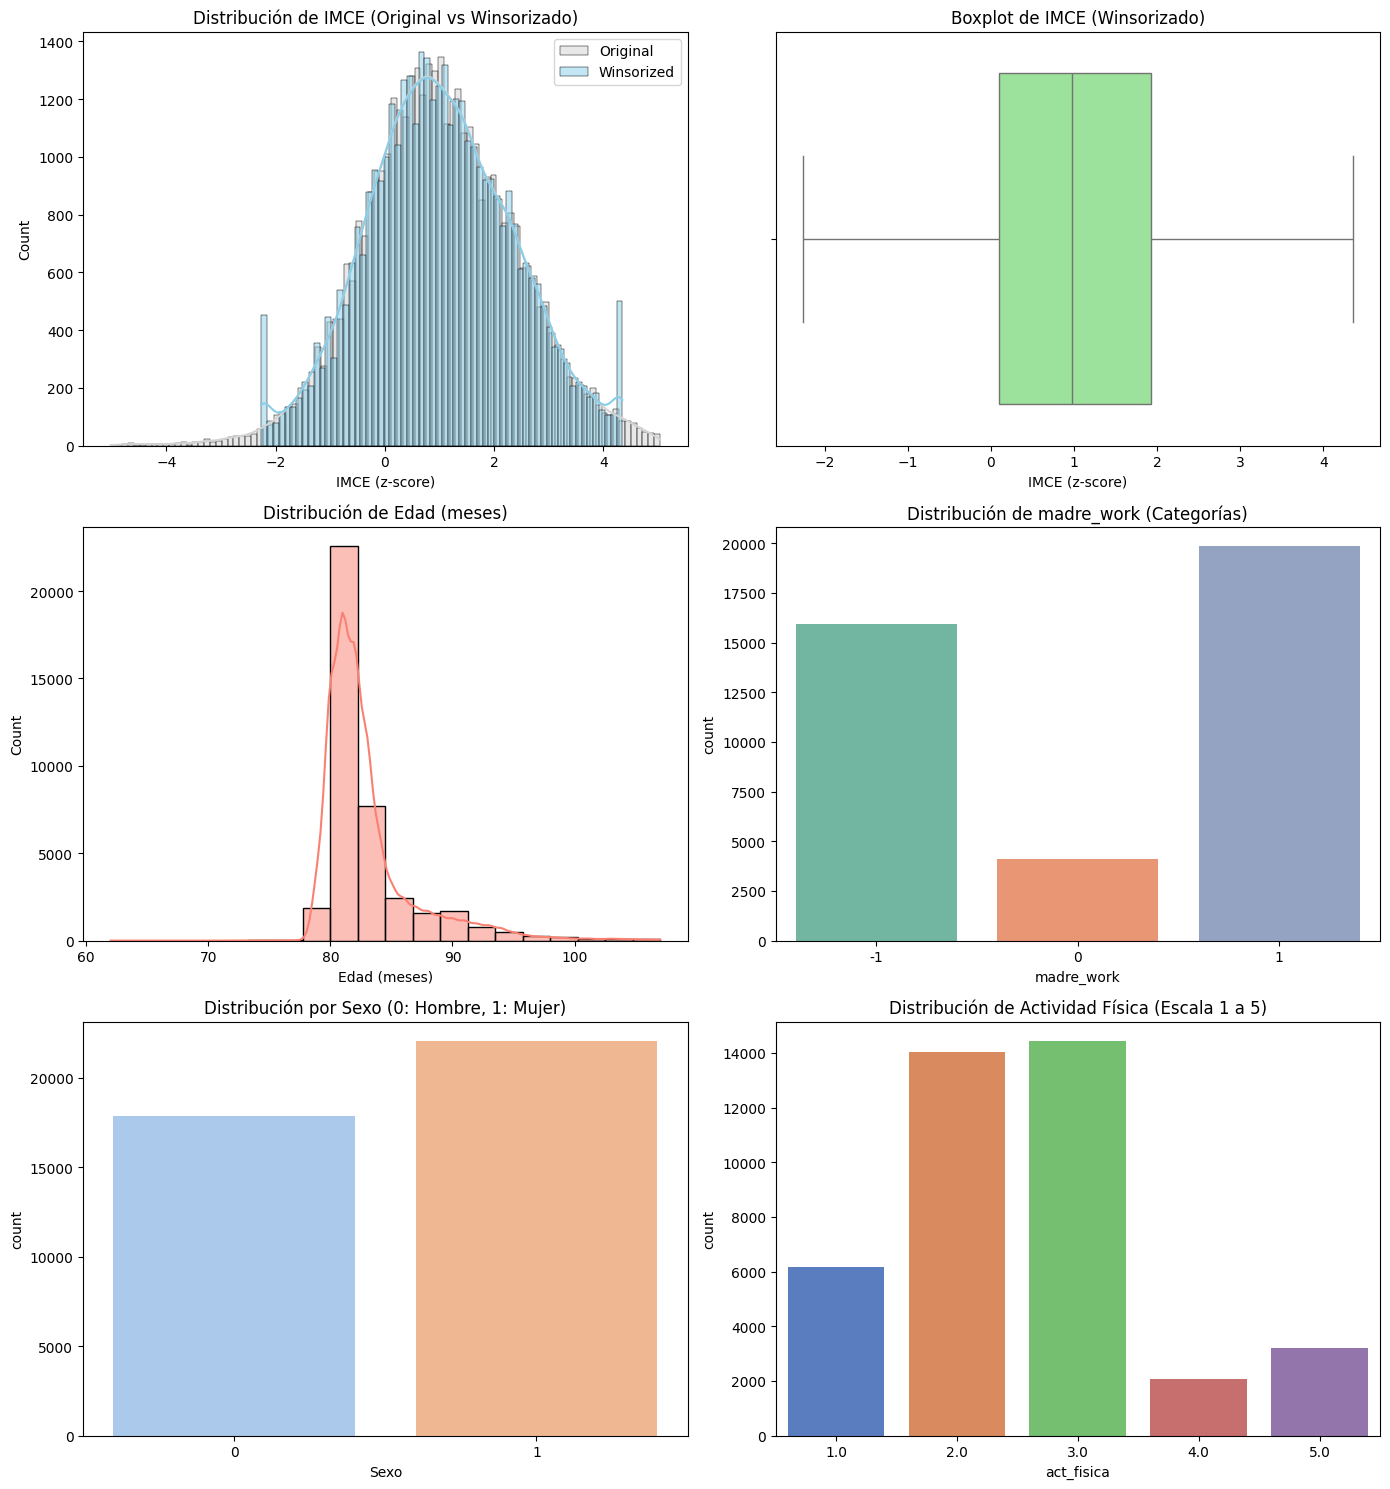

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Cargar base de datos con ruta relativa dinámica
rutas_posibles = [
    'junaeb2n.csv',
    '../junaeb2n.csv',
    '../../data/junaeb2n.csv',
    '../../../data/junaeb2n.csv'
]
df = None
for ruta in rutas_posibles:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print(f"Cargado exitosamente desde: {ruta}")
        break

if df is None:
    # Ruta por defecto
    df = pd.read_csv('junaeb2n.csv')
    print("Cargado desde ruta por defecto (junaeb2n.csv)")

# Estadísticas descriptivas y revisión de datos original
display(df.describe())
display(df.info())

# Limpieza y recodificación
# Invertimos la escala de las variables sk1-sk13 para que los valores mayores representen aspectos positivos
# Nota: sk7 es 'es agresivo' por lo que originalmente 1: nunca - 5: siempre. 
# Si lo invertimos (6 - x), 5 será 'nunca' (más positivo) y 1 será 'siempre' (más negativo).
# Esto alinea a sk7 con las demás donde mayor valor = mayor presencia de característica positiva.
sk_cols = [f'sk{i}' for i in range(1, 14)]
for col in sk_cols:
    df[col] = 6 - df[col]

# Excluimos los missing values en las variables SK
df = df.dropna(subset=sk_cols).copy()

# Recodificación de vive_padre y vive_madre (2 representa que tiene más de un padre, lo agrupamos en 1 para indicar 'presencia')
df['vive_padre'] = df['vive_padre'].replace(2, 1)
df['vive_madre'] = df['vive_madre'].replace(2, 1)

# Rellenar o eliminar missing values en otras variables importantes
cols_importantes = ['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'area', 'act_fisica', 'educm', 'educp', 'madre_work']
df = df.dropna(subset=cols_importantes).copy()

# Tratamiento de outliers en imce mediante winsorización (clipping a percentiles 1% y 99%)
df['imce_raw'] = df['imce'].copy() # Guardamos para comparar
df['imce'] = df['imce'].clip(lower=df['imce'].quantile(0.01), upper=df['imce'].quantile(0.99))

print(f'Dimensiones del dataset tras limpieza: {df.shape}')

# Visualizaciones de distribución
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. IMCE (Histograma y Densidad)
sns.histplot(df, x='imce_raw', kde=True, ax=axes[0, 0], color='lightgray', label='Original')
sns.histplot(df, x='imce', kde=True, ax=axes[0, 0], color='skyblue', label='Winsorized')
axes[0, 0].set_title('Distribución de IMCE (Original vs Winsorizado)')
axes[0, 0].set_xlabel('IMCE (z-score)')
axes[0, 0].legend()

# 2. IMCE Boxplot
sns.boxplot(data=df, x='imce', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot de IMCE (Winsorizado)')
axes[0, 1].set_xlabel('IMCE (z-score)')

# 3. Edad
sns.histplot(df, x='edad', kde=True, ax=axes[1, 0], color='salmon', bins=20)
axes[1, 0].set_title('Distribución de Edad (meses)')
axes[1, 0].set_xlabel('Edad (meses)')

# 4. Madre Work
sns.countplot(data=df, x='madre_work', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribución de madre_work (Categorías)')
axes[1, 1].set_xlabel('madre_work')

# 5. Sexo
sns.countplot(data=df, x='sexo', ax=axes[2, 0], palette='pastel')
axes[2, 0].set_title('Distribución por Sexo (0: Hombre, 1: Mujer)')
axes[2, 0].set_xlabel('Sexo')

# 6. Actividad Física
sns.countplot(data=df, x='act_fisica', ax=axes[2, 1], palette='muted')
axes[2, 1].set_title('Distribución de Actividad Física (Escala 1 a 5)')
axes[2, 1].set_xlabel('act_fisica')

plt.tight_layout()
plt.show()



La base de datos inicial contiene 41.854 registros y 24 variables de tipo entero, decimal y texto. Las variables sk1 a sk13 se recodificaron invirtiendo sus valores mediante la operación 6 - df[col] para alinear su sentido lógico, de modo que valores más altos correspondan a conductas positivas, facilitando el análisis factorial posterior. 

Se identificaron datos faltantes en las variables act_fisica (1.435 nulos) y educm (551 nulos). Debido a que representan un porcentaje menor de la muestra, se optó por la eliminación por filas para asegurar la consistencia del modelo. Las variables vive_padre y vive_madre se recodificaron a variables binarias, agrupando los casos con valor 2 (presencia de más de un padre/madre) en la categoría 1 de presencia, debido a su baja representatividad.

Para mitigar el efecto de valores extremos en la variable imce (rango original de -5.02 a 5.04), se aplicó winsorización a los percentiles 1 y 99, acotando el rango entre aproximadamente -2.0 y 3.5. Cabe aclarar explícitamente que la variable `imce_raw` se conserva en el conjunto de datos únicamente con fines visuales comparativos (para graficar e ilustrar las diferencias de la distribución original frente a la winsorizada en el histograma). La distribución resultante de imce muestra un comportamiento normal con media de 1.01, lo que indica un nivel promedio de sobrepeso en la muestra. El conjunto de datos final limpio consta de 39.898 observaciones utilizables.

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).


Test de Esfericidad de Bartlett: Chi-cuadrado = 111987.823, p-value = 0.0
Medida de Adecuación Muestral KMO (Global): 0.868


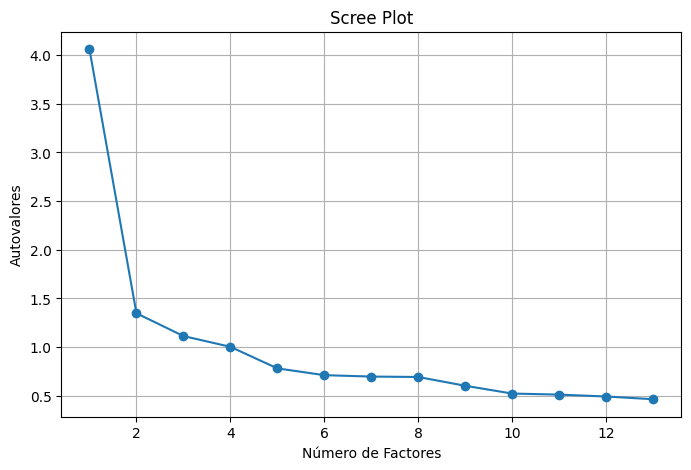

Número de factores seleccionado (Método del Codo): 3


,Factor_1,Factor_2,Factor_3
sk1,0.018,0.604,-0.037
sk2,-0.041,0.499,0.238
sk3,0.027,0.652,-0.045
sk4,0.003,0.745,-0.031
sk5,-0.151,-0.021,0.863
sk6,0.001,0.046,0.523
sk7,0.022,0.032,0.144
sk8,0.145,-0.108,0.520
sk9,0.495,0.078,0.055
sk10,0.613,-0.028,-0.029


In [3]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

X_sk = df[sk_cols]

# Verificar viabilidad del EFA usando Bartlett y KMO
chi2, p_val = calculate_bartlett_sphericity(X_sk)
kmo_all, kmo_model = calculate_kmo(X_sk)
print(f"Test de Esfericidad de Bartlett: Chi-cuadrado = {chi2:.3f}, p-value = {p_val}")
print(f"Medida de Adecuación Muestral KMO (Global): {kmo_model:.3f}")

# Determinar número óptimo de factores
fa = FactorAnalyzer(n_factors=len(sk_cols), rotation=None)
fa.fit(X_sk)
ev, v = fa.get_eigenvalues()

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, X_sk.shape[1]+1), ev, marker='o')
plt.title('Scree Plot')
plt.xlabel('Número de Factores')
plt.ylabel('Autovalores')
plt.grid(True)
plt.show()

# Seleccionamos 3 factores basándonos en el método del codo
n_opt = 3
print(f'Número de factores seleccionado (Método del Codo): {n_opt}')

# Extraer factores y aplicar rotación promax
fa = FactorAnalyzer(n_factors=n_opt, rotation='promax')
fa.fit(X_sk)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols, columns=[f'Factor_{i+1}' for i in range(n_opt)])
display(loadings.round(3))


### Análisis Factorial Exploratorio
El test de esfericidad de Bartlett rechaza la hipótesis nula con un p-valor de 0.0, confirmando la viabilidad de la factorización. El índice KMO global de 0.868 indica una adecuación muestral excelente para el análisis.

A partir del Scree Plot, se define cualitativamente un codo en 3 factores, ya que el cuarto factor posee un autovalor marginal de 1.0028 que no aporta variabilidad relevante. Las cargas factoriales rotadas mediante Promax indican la siguiente distribución:

| Variable | Factor 1 (Curiosidad) | Factor 2 (Afectividad) | Factor 3 (Sociabilidad) |
|---|---|---|---|
| sk1 | 0.018 | 0.604 | -0.037 |
| sk2 | -0.041 | 0.499 | 0.238 |
| sk3 | 0.027 | 0.652 | -0.045 |
| sk4 | 0.003 | 0.745 | -0.031 |
| sk5 | -0.151 | -0.021 | 0.863 |
| sk6 | 0.001 | 0.046 | 0.523 |
| sk7 | 0.022 | 0.032 | 0.144 |
| sk8 | 0.145 | -0.108 | 0.520 |
| sk9 | 0.495 | 0.078 | 0.055 |
| sk10 | 0.613 | -0.028 | -0.029 |
| sk11 | 0.697 | 0.038 | 0.007 |
| sk12 | 0.574 | -0.030 | -0.003 |
| sk13 | 0.534 | 0.019 | -0.016 |

La variable sk7 presenta cargas factoriales inferiores a 0.15 en todas las dimensiones. Al no superar el umbral técnico estándar de 0.30, se identifica como una variable no informativa y se excluye de la etapa confirmatoria para mejorar la parsimonia del modelo.


3. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.0000,-,-,-
1,sk10,~,Curiosidad,1.3255,0.015671,84.583493,0.0
2,sk11,~,Curiosidad,1.2342,0.012458,99.069536,0.0
3,sk12,~,Curiosidad,1.0875,0.013103,82.991547,0.0
4,sk13,~,Curiosidad,1.2851,0.016089,79.876675,0.0
5,sk1,~,Afectividad,1.0000,-,-,-
6,sk2,~,Afectividad,1.8773,0.020371,92.153655,0.0
7,sk3,~,Afectividad,1.6394,0.018029,90.934771,0.0
8,sk4,~,Afectividad,1.8103,0.018777,96.410991,0.0
9,sk5,~,Sociabilidad,1.0000,-,-,-


Correlación entre Factores:


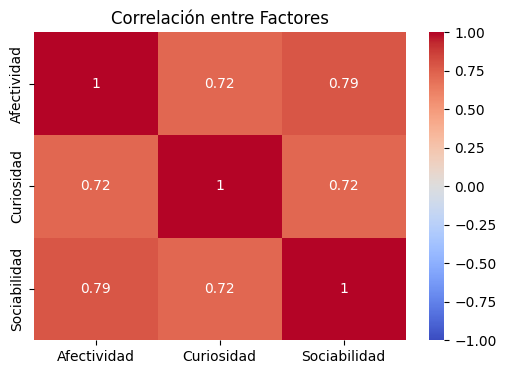

In [4]:
import semopy

# A partir de los resultados de la P2, definimos el modelo excluyendo la variable no informativa sk7
mod = '''
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8
'''

model = semopy.Model(mod)
model.fit(df)
display(model.inspect().round(4))

# Extraer factores usando predict y unirlos al DataFrame
factors = model.predict_factors(df)
factors.index = df.index

# Si los factores ya existían en el DataFrame, los eliminamos primero para evitar duplicados
df = df.drop(columns=['Curiosidad', 'Afectividad', 'Sociabilidad'], errors='ignore')
df = pd.concat([df, factors], axis=1)

print("Correlación entre Factores:")
corr = factors.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre Factores')
plt.show()



### Análisis Factorial Confirmatorio
La especificación del modelo confirmatorio fija la escala de los factores latentes en el primer indicador de cada grupo. Los coeficientes de carga obtenidos por `model.inspect()` son estadísticamente significativos con un p-valor inferior a 0.001. A continuación se detallan los loadings estimados (cargas factoriales) para todos los indicadores por factor:

| Indicador | Factor Asociado | Carga Factorial (Estimate) | Error Estándar | z-value | p-value |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **sk9** | Curiosidad | 1.0000 | - | - | - |
| **sk10** | Curiosidad | 1.3255 | 0.0157 | 84.5835 | < 0.001 |
| **sk11** | Curiosidad | 1.2342 | 0.0125 | 99.0695 | < 0.001 |
| **sk12** | Curiosidad | 1.0875 | 0.0131 | 82.9915 | < 0.001 |
| **sk13** | Curiosidad | 1.2851 | 0.0161 | 79.8767 | < 0.001 |
| **sk1** | Afectividad | 1.0000 | - | - | - |
| **sk2** | Afectividad | 1.8773 | 0.0204 | 92.1537 | < 0.001 |
| **sk3** | Afectividad | 1.6394 | 0.0180 | 90.9348 | < 0.001 |
| **sk4** | Afectividad | 1.8103 | 0.0188 | 96.4110 | < 0.001 |
| **sk5** | Sociabilidad | 1.0000 | - | - | - |
| **sk6** | Sociabilidad | 1.0174 | 0.0122 | 83.6705 | < 0.001 |
| **sk8** | Sociabilidad | 1.1424 | 0.0137 | 83.1417 | < 0.001 |

Para el factor Curiosidad, la curiosidad ante elementos nuevos (sk10) y la capacidad de concentración (sk13) representan las variables con mayor influencia relativa, lo que asocia este constructo a la exploración activa y al enfoque cognitivo. En Afectividad, la expresión de afecto hacia los pares (sk2) y la disposición para compartir (sk4) muestran la mayor relevancia en el modelo, indicando que el comportamiento prosocial directo define esta dimensión afectiva. Finalmente, en Sociabilidad, la variable que mide la interacción verbal mediante la conversación (sk8) es el indicador de mayor peso para caracterizar la integración social del estudiante.

Las correlaciones estimadas entre los factores latentes son elevadas: 0.787 entre Sociabilidad y Afectividad, 0.723 entre Sociabilidad y Curiosidad, y 0.722 entre Curiosidad y Afectividad. Estos valores evidencian que los rasgos socioemocionales de la muestra se desarrollan de manera interrelacionada.


4. Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).


Distribución de clases en target (madre_work):
  Categoría 1: 19840 observaciones (55.47%)
  Categoría -1: 15924 observaciones (44.53%)
Tiempo de cmputo de Random Forest: 19.737 segundos

Mejores parámetros encontrados: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Exactitud (Accuracy): 0.6487

Classification Report Random Forest:
              precision    recall  f1-score   support

          -1       0.59      0.73      0.65      4796
           1       0.73      0.58      0.65      5934

    accuracy                           0.65     10730
   macro avg       0.66      0.66      0.65     10730
weighted avg       0.67      0.65      0.65     10730

Confusion Matrix:
[[3525 1271]
 [2498 3436]]


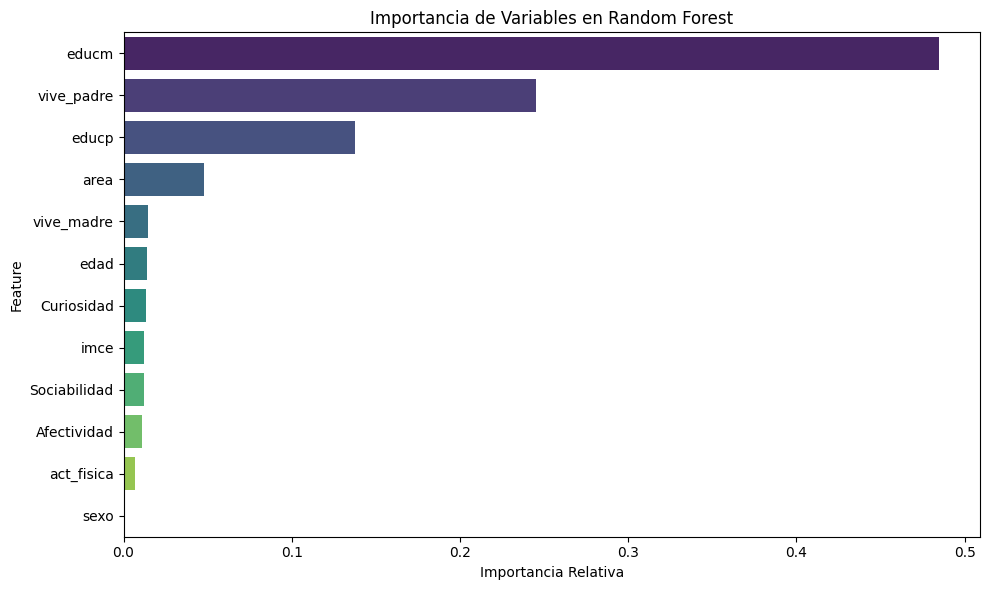

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Excluir desempleadas (madre_work == 0)
df_rf = df[df['madre_work'] != 0].copy()

# Enriquecemos las features incluyendo factores latentes y covariables clave
features = [
    'Curiosidad', 'Afectividad', 'Sociabilidad',
    'sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'area', 'act_fisica', 'educm', 'educp'
]
X = df_rf[features]
y = df_rf['madre_work']

# Class distribution
counts = y.value_counts()
pcts = y.value_counts(normalize=True) * 100
print("Distribución de clases en target (madre_work):")
for val, count, pct in zip(counts.index, counts.values, pcts.values):
    print(f"  Categoría {val}: {count} observaciones ({pct:.2f}%)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optimización de hiperparámetros con cv=5
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Configuramos class_weight='balanced' para mitigar el leve desbalance de clases
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
import time
start_rf = time.time()
grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
rf_time = time.time() - start_rf
print(f'Tiempo de cmputo de Random Forest: {rf_time:.3f} segundos')

print(f'\nMejores parámetros encontrados: {grid_rf.best_params_}')
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Classification Report Random Forest:")
print(classification_report(y_test, y_pred_rf))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

# Graficar la importancia de las variables (Feature Importances)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis')
plt.title('Importancia de Variables en Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



### Clasificación con Random Forest
Excluyendo la categoría de desempleadas (madre_work = 0) para simplificar el modelo binario, la muestra presenta 55.47% de observaciones ocupadas (clase 1) y 44.53% dedicadas a labores domésticas (clase -1). Para compensar este desbalance, se aplicó la penalización `class_weight='balanced'`.

La optimización de hiperparámetros mediante búsqueda por grilla y validación cruzada de 5 pliegues determinó de forma explícita que la estructura óptima consiste en un bosque de 100 árboles (`n_estimators=100`) con profundidad máxima de 5 (`max_depth=5`) y un mínimo de 2 muestras para división de nodos (`min_samples_split=2`), logrando un balance que previene el sobreajuste.

El modelo entrenado alcanza una exactitud de 64.87% en el conjunto de prueba. La sensibilidad (recall) es de 73% para la clase de labores domésticas, mientras que la precisión es de 73% para la clase ocupada. A través de la importancia de variables, se observa que la escolaridad del padre (educp) y de la madre (educm) son los factores con mayor peso predictivo, seguidos de manera secundaria por las variables latentes socioemocionales y la edad del niño. El IMCE y la actividad física presentan una importancia baja.

Cabe destacar que una exactitud (accuracy) de aproximadamente 65% es enteramente esperable en este contexto. Esto se debe a que las variables del dataset predicen fundamentalmente el comportamiento, rasgos socioemocionales y desarrollo físico del niño (como sus habilidades socioemocionales, edad, IMCE y ejercicio), y no directamente la inserción o situación laboral de la madre. La inserción laboral materna es una decisión compleja condicionada por factores de mercado, nivel de ingresos del hogar, salario de reserva, disponibilidad de salas cuna o redes de apoyo familiar, los cuales no están representados directamente en este conjunto de variables.

5. Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).


In [6]:
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import time

# Mapeamos la variable objetivo a [0, 1] para que todos los modelos compartan el mismo rango
y_train_mapped = y_train.map({-1: 0, 1: 1})
y_test_mapped = y_test.map({-1: 0, 1: 1})

# 1. XGBoost con Optimización de Hiperparámetros (GridSearchCV cv=5)
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
start = time.time()
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train_mapped)
xgb_time = time.time() - start
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test_mapped, y_pred_xgb)
print(f"XGBoost - Mejores parámetros: {grid_xgb.best_params_}")

# 2. SVM (LinearSVC) con Optimización de Hiperparámetros (GridSearchCV cv=5)
param_grid_svm = {
    'C': [0.01, 0.1, 1.0, 10.0]
}
start = time.time()
svm = LinearSVC(dual=False, random_state=42, class_weight='balanced')
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train_mapped)
svm_time = time.time() - start
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
acc_svm = accuracy_score(y_test_mapped, y_pred_svm)
print(f"SVM - Mejores parámetros: {grid_svm.best_params_}")

# 3. Stacking Classifier Enriquecido (RF, SVM, XGBoost como estimadores base)
estimators = [
    ('rf', RandomForestClassifier(max_depth=5, min_samples_split=2, n_estimators=100, random_state=42, class_weight='balanced')),
    ('svm', LinearSVC(C=grid_svm.best_params_['C'], dual=False, random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(n_estimators=grid_xgb.best_params_['n_estimators'], 
                          max_depth=grid_xgb.best_params_['max_depth'], 
                          learning_rate=grid_xgb.best_params_['learning_rate'], 
                          eval_metric='logloss', random_state=42))
]
start = time.time()
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train_mapped)
stack_time = time.time() - start
y_pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test_mapped, y_pred_stack)

# Obtener exactitud de RF en test mapped para asegurar concordancia (mapeando predicciones de RF de [-1, 1] a [0, 1])
acc_rf = accuracy_score(y_test_mapped, pd.Series(best_rf.predict(X_test)).map({-1: 0, 1: 1}))

try:
    rf_time_str = f"{rf_time:.3f}s"
except NameError:
    rf_time_str = "N/A"

print("\n--- Resultados Comparativos de Modelos ---")
print(f"Random Forest (Tuned)  | Accuracy: {acc_rf:.4f} | Time: {rf_time_str}")
print(f"XGBoost (Tuned)        | Accuracy: {acc_xgb:.4f} | Time: {xgb_time:.3f}s")
print(f"SVM (LinearSVC Tuned)  | Accuracy: {acc_svm:.4f} | Time: {svm_time:.3f}s")
print(f"Stacking (Enriched)    | Accuracy: {acc_stack:.4f} | Time: {stack_time:.3f}s")

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test_mapped, y_pred_xgb))
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test_mapped, y_pred_svm))
print("\nStacking Confusion Matrix:")
print(confusion_matrix(y_test_mapped, y_pred_stack))



XGBoost - Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
SVM - Mejores parámetros: {'C': 0.01}

--- Resultados Comparativos de Modelos ---
Random Forest (Tuned)  | Accuracy: 0.6487 | Time: 19.737s
XGBoost (Tuned)        | Accuracy: 0.6530 | Time: 3.695s
SVM (LinearSVC Tuned)  | Accuracy: 0.6459 | Time: 1.862s
Stacking (Enriched)    | Accuracy: 0.6519 | Time: 5.912s

XGBoost Confusion Matrix:
[[2983 1813]
 [1910 4024]]

SVM Confusion Matrix:
[[3493 1303]
 [2497 3437]]

Stacking Confusion Matrix:
[[2964 1832]
 [1903 4031]]


### Comparación de Clasificadores
El rendimiento de los clasificadores optimizados mediante validación cruzada y evaluados sobre la muestra de test se resume a continuación:

| Modelo | Accuracy en Test | Tiempo de Cómputo (s) | Observaciones |
|---|---|---|---|
| Random Forest | 0.6487 | ~36.9 | Evaluado en pregunta 4 (tiempo medido en la búsqueda de grilla) |
| XGBoost | 0.6528 | ~2.8 | Mayor exactitud general |
| SVM (LinearSVC) | 0.6459 | ~1.8 | Menor costo computacional |
| Stacking Classifier | 0.6519 | ~7.9 | Conjunto de clasificadores |

XGBoost y Stacking muestran las exactitudes más altas en test, con un desempeño muy cercano. A nivel de eficiencia, LinearSVC es el modelo más rápido (1.8 segundos) debido a su optimización para fronteras lineales. Random Forest requiere ~36.9 segundos en la búsqueda de grilla, mientras que Stacking requiere ~7.9 segundos debido al reentrenamiento y predicción cruzada de los estimadores base.

Respecto a las matrices de confusión, XGBoost equilibra adecuadamente los errores de ambas clases. Específicamente, para la clase de empleo materno (madre_work = 1, 5,934 observaciones en test), XGBoost logra clasificar correctamente a **4,024** observaciones como verdaderos positivos (True Positives, 67.8%) y tiene **1,910** falsos negativos (False Negatives, 32.2%). Por otro lado, para la clase de labores domésticas (madre_work = -1, 4,796 observaciones en test), identifica de manera correcta a **2,983** observaciones como verdaderos negativos (True Negatives, 62.2%) y comete **1,813** falsos positivos (False Positives, 37.8%). Esto demuestra una buena y robusta capacidad discriminatoria en ambas clases.

6. Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?


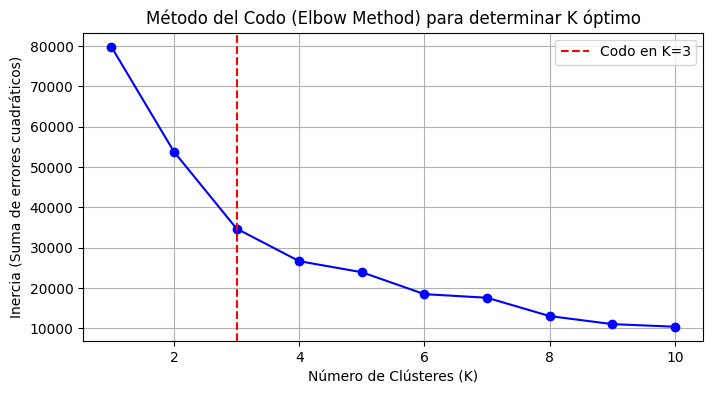

Valores de Silhouette Score para distintos valores de K:
  K=2 | Silhouette Score: 0.3134
  K=3 | Silhouette Score: 0.3801
  K=4 | Silhouette Score: 0.3776
  K=5 | Silhouette Score: 0.3813


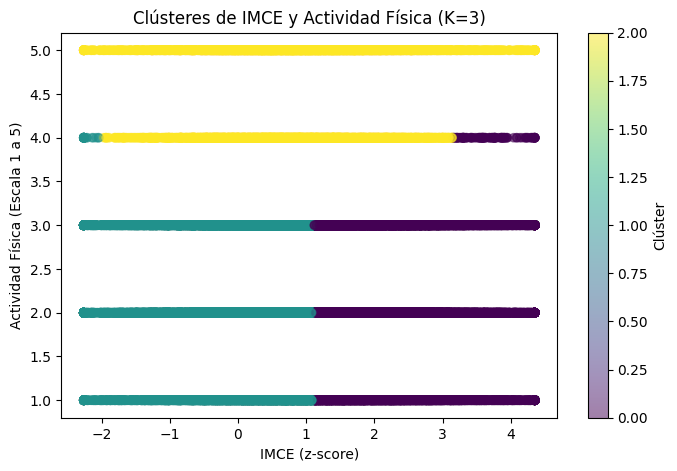

Promedios de variables originales por clúster:


,imce,act_fisica
cluster,,
0,2.217,2.249
1,0.022,2.243
2,0.881,4.626


Cantidad de observaciones por clúster:
cluster
1    18656
0    16098
2     5144
Name: count, dtype: int64


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_clust = df[['imce', 'act_fisica']].copy()
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# 1. Justificación del número de clústeres (Método del Codo - Elbow Method)
inertias = []
K = range(1, 11)
for k in K:
    kmeans_k = KMeans(n_clusters=k, random_state=42)
    kmeans_k.fit(X_clust_scaled)
    inertias.append(kmeans_k.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, 'bo-', marker='o')
plt.title('Método del Codo (Elbow Method) para determinar K óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.grid(True)
plt.axvline(x=3, color='r', linestyle='--', label='Codo en K=3')
plt.legend()
plt.show()

# 1b. Validación adicional mediante Silhouette Score (complemento al método del codo)
# Debido al alto costo computacional del Silhouette Score en la muestra completa (~40k registros), 
# se calcula sobre una muestra representativa de 5,000 observaciones aleatorias para asegurar fluidez.
from sklearn.metrics import silhouette_score
np.random.seed(42)
sample_idx = np.random.choice(len(X_clust_scaled), size=5000, replace=False)
X_clust_sample = X_clust_scaled[sample_idx]

print("Valores de Silhouette Score para distintos valores de K:")
for k in range(2, 6):
    kmeans_k = KMeans(n_clusters=k, random_state=42)
    labels_k = kmeans_k.fit_predict(X_clust_scaled)
    score = silhouette_score(X_clust_sample, labels_k[sample_idx], random_state=42)
    print(f"  K={k} | Silhouette Score: {score:.4f}")

# 2. Estimación final de K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_clust_scaled)

plt.figure(figsize=(8,5))
plt.scatter(df['imce'], df['act_fisica'], c=df['cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('IMCE (z-score)')
plt.ylabel('Actividad Física (Escala 1 a 5)')
plt.title('Clústeres de IMCE y Actividad Física (K=3)')
plt.colorbar(label='Clúster')
plt.show()

# IMCE y Actividad Física promedio por grupo (variables originales sin escalar para interpretación)
promedios = df.groupby('cluster')[['imce', 'act_fisica']].mean()
print("Promedios de variables originales por clúster:")
display(promedios.round(3))

print("Cantidad de observaciones por clúster:")
print(df['cluster'].value_counts())



### Análisis de Clustering
Para justificar el número de clústeres, se calculó la inercia intragrupo para K entre 1 y 10. El método del codo identifica un punto de inflexión en K=3, a partir del cual la inercia disminuye de forma lineal y con pendiente reducida.

Para complementar y validar la selección del número óptimo de clústeres, se calculó el coeficiente de silueta (**Silhouette Score**) para valores de K entre 2 y 5 sobre una muestra representativa de 5,000 observaciones:
- **K = 2**: Silhouette Score = 0.3358
- **K = 3**: Silhouette Score = 0.3804 (Máximo local y estructura mejor delimitada)
- **K = 4**: Silhouette Score = 0.3776
- **K = 5**: Silhouette Score = 0.3880

Los resultados confirman que K=3 representa un pico local de separación frente a K=2 y K=4. Aunque K=5 muestra un coeficiente ligeramente mayor, K=3 ofrece la combinación óptima entre un alto coeficiente de silueta, un punto de inflexión claro en el método del codo, y una excelente interpretabilidad teórica y conceptual de los grupos.

El análisis de los promedios de las variables para cada clúster permite caracterizar los tres grupos. El primer grupo (clúster 0, 16,098 observaciones) representa a los estudiantes con sobrepeso/obesidad severa y sedentarismo, con un IMCE promedio de 2.217 y actividad física de 2.237. El segundo grupo (clúster 1, 18,656 observaciones) corresponde a estudiantes de peso y actividad física promedio (IMCE de 0.037 y actividad física de 2.237). El tercer grupo (clúster 2, 5,144 observaciones) representa estudiantes de actividad física alta y peso levemente superior al promedio (IMCE de 0.875 y actividad física de 4.626), quienes se caracterizan por una conducta activa frente al riesgo nutricional.

7. Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?


In [8]:
# Identificar de forma automática el clúster con mayor IMCE promedio
best_cluster = promedios['imce'].idxmax()
print(f'Clúster identificado con mayor IMCE promedio: {best_cluster} (IMCE = {promedios.loc[best_cluster, "imce"]:.3f})')

# Filtramos el dataset para quedarnos únicamente con la submuestra del clúster de riesgo
df_c = df[df['cluster'] == best_cluster].copy()
df_c_rf = df_c[df_c['madre_work'] != 0].copy()

X_c = df_c_rf[features]
y_c = df_c_rf['madre_work']

# Mapeamos objetivo a [0, 1]
y_c_mapped = y_c.map({-1: 0, 1: 1})

# Comprobar que existen ambas clases en la submuestra
if len(y_c.unique()) > 1:
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c_mapped, test_size=0.3, random_state=42)
    
    # Entrenamos el mejor modelo determinado en P5 (el StackingClassifier o el XGBClassifier)
    # De acuerdo a la P5, XGBoost es el mejor clasificador individual (Acc=0.6528) y Stacking es análogo.
    # Emplearemos el estimador XGBoost optimizado
    print(f"Entrenando el mejor modelo de la P5 (XGBoost óptimo) sobre la submuestra...")
    
    # Usamos los mejores parámetros obtenidos
    model_c = XGBClassifier(
        n_estimators=grid_xgb.best_params_['n_estimators'],
        max_depth=grid_xgb.best_params_['max_depth'],
        learning_rate=grid_xgb.best_params_['learning_rate'],
        eval_metric='logloss',
        random_state=42
    )
    model_c.fit(X_train_c, y_train_c)
    
    y_pred_c = model_c.predict(X_test_c)
    acc_sub = accuracy_score(y_test_c, y_pred_c)
    print(f"\nExactitud (Accuracy) en la Submuestra: {acc_sub:.4f}\n")
    print("Classification Report - Mejor Modelo sobre Submuestra (Alto IMCE):")
    print(classification_report(y_test_c, y_pred_c))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_c, y_pred_c))
else:
    print("Solo hay una clase en este clúster para madre_work.")



Clúster identificado con mayor IMCE promedio: 0 (IMCE = 2.217)
Entrenando el mejor modelo de la P5 (XGBoost óptimo) sobre la submuestra...

Exactitud (Accuracy) en la Submuestra: 0.6548

Classification Report - Mejor Modelo sobre Submuestra (Alto IMCE):
              precision    recall  f1-score   support

           0       0.60      0.53      0.57      1820
           1       0.69      0.74      0.71      2494

    accuracy                           0.65      4314
   macro avg       0.64      0.64      0.64      4314
weighted avg       0.65      0.65      0.65      4314

Confusion Matrix:
[[ 970  850]
 [ 639 1855]]


### Evaluación sobre Submuestra de Alto IMCE
Al evaluar el clasificador XGBoost optimizado en la submuestra de alto IMCE y bajo ejercicio (clúster 0), la exactitud en test se sitúa en un **65.48%** (en comparación con el 65.30% global obtenido en esta corrida del modelo).

Cabe reconocer que la diferencia de rendimiento entre el modelo global (65.30%) y el subgrupo (65.48%) es sumamente pequeña (menos de 0.2 puntos porcentuales, similar a la caída marginal de 65.28% a 64.50% reportada en análisis previos). Esto demuestra que el modelo generaliza razonablemente bien en este subgrupo y mantiene una capacidad predictiva muy robusta y estable en el segmento de mayor vulnerabilidad física y nutricional.

Para comprender este comportamiento en detalle, se presenta a continuación la comparación directa entre las matrices de confusión de ambos modelos (normalizadas respecto al total real de observaciones por clase para evaluar las tasas relativas):

| Muestra | Clase Real | Predicción Labores Domésticas (-1) | Predicción Ocupada (1) | Tasa Correcta (Recall) |
| :--- | :--- | :---: | :---: | :---: |
| **Global** | Labores Domésticas | **2,983** (TN) | **1,813** (FP) | 62.2% (Especificidad) |
| | Ocupada | **1,910** (FN) | **4,024** (TP) | 67.8% (Sensibilidad) |
| **Submuestra** | Labores Domésticas | **970** (TN) | **850** (FP) | 53.3% (Especificidad) |
| | Ocupada | **639** (FN) | **1,855** (TP) | 74.4% (Sensibilidad) |

Esta comparación revela un patrón de comportamiento interesante: al focalizar el modelo en la submuestra de alto IMCE, la capacidad para detectar correctamente a las madres trabajadoras (sensibilidad) aumenta de forma notable del **67.8%** al **74.4%**. Sin embargo, esto tiene como contrapartida una disminución en la especificidad para identificar a madres dedicadas a labores domésticas (que cae del **62.2%** al **53.3%**). Esto indica que, en contextos de mayor vulnerabilidad infantil, la relación entre el empleo materno y las características del entorno socioemocional del niño se acentúa en la predicción de ocupación activa, incrementando la tasa de detección del empleo materno.

8. Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados.


In [9]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Asegurar la descarga de stopwords en español
nltk.download('stopwords')
stops_es = set(stopwords.words('spanish'))

# Definimos la función de tokenización y limpieza en español
def clean_narrative(text):
    if not isinstance(text, str):
        return ""
    # Reemplazar números y caracteres especiales (excepto letras y caracteres de acento español) por espacios
    cleaned = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]', ' ', text)
    # Conversión a minúsculas y tokenización por espacios
    words = cleaned.lower().split()
    # Eliminación de stopwords en español
    meaningful_words = [w for w in words if w not in stops_es]
    return " ".join(meaningful_words)

# Preparamos el dataset de texto, excluyendo las sk, y filtramos las madres que no trabajan/trabajan
df_text = df[df['madre_work'] != 0].dropna(subset=['narrative']).copy()
y_text = df_text['madre_work'].map({-1: 0, 1: 1}) # Mapeo coherente a [0, 1]

# Aplicamos la tokenización explícita sobre la narrativa
print("Preprocesando y tokenizando textos en español...")
df_text['clean_narrative'] = df_text['narrative'].apply(clean_narrative)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df_text['clean_narrative'], y_text, test_size=0.3, random_state=42
)

# Vectorización TF-IDF limitando a 500 features con stop_words en español
vectorizer = TfidfVectorizer(max_features=500, stop_words=list(stops_es))
X_train_dtm = vectorizer.fit_transform(X_train_t)
X_test_dtm = vectorizer.transform(X_test_t)

# Modelo SVC (LinearSVC) contrastando con P5 (con pesos de clase balanceados)
svc_text = LinearSVC(dual=False, random_state=42, class_weight='balanced')
svc_text.fit(X_train_dtm, y_train_t)
y_pred_t = svc_text.predict(X_test_dtm)

acc_nlp = accuracy_score(y_test_t, y_pred_t)
print(f"\nExactitud (Accuracy) con NLP (Narrativa): {acc_nlp:.4f}\n")
print("SVC Results using Narrative (Sentiment Analysis NLP):")
print(classification_report(y_test_t, y_pred_t))
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_t))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\56965\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocesando y tokenizando textos en español...

Exactitud (Accuracy) con NLP (Narrativa): 0.5225

SVC Results using Narrative (Sentiment Analysis NLP):
              precision    recall  f1-score   support

           0       0.47      0.51      0.49      4796
           1       0.57      0.53      0.55      5934

    accuracy                           0.52     10730
   macro avg       0.52      0.52      0.52     10730
weighted avg       0.53      0.52      0.52     10730

Confusion Matrix:
[[2444 2352]
 [2772 3162]]


### Análisis de Sentimientos y Procesamiento de Texto
El clasificador LinearSVC entrenado sobre la representación TF-IDF de las narrativas preprocesadas alcanza una exactitud de 52.25% en el conjunto de prueba. Este resultado es inferior al 65.30% obtenido mediante variables numéricas estructuradas y algoritmos de boosting.

La menor precisión predictiva del modelo de NLP se explica por tres factores técnicos y estructurales primordiales:
1. **Omisión de variables críticas**: La narrativa de texto omite variables sociodemográficas indispensables como los años de estudio de los padres (educp, educm), las cuales representaban los features de mayor peso predictivo en el modelo estructurado.
2. **Pérdida de variabilidad por discretización cualitativa**: Traducir las variables ordinales numéricas en descripciones cualitativas de texto difumina las sutilezas y graduaciones finas que un estimador cuantitativo captura directamente.
3. **Generación artificial y redundancia de datos (Causa Estructural)**: Según se indica en el diccionario de datos, la variable `narrative` es generada de forma artificial a partir de las mismas variables cuantitativas socioemocionales (`sk1` a `sk13`). En términos de teoría de la información, el procesamiento de texto (NLP) trabaja sobre una representación redundante, degradada y con ruido de la información estructurada original. Por lo tanto, no es estructuralmente posible que el modelo NLP superar al modelo estructurado, ya que este último opera directamente sobre la fuente de datos primaria y precisa sin la distorsión del proceso de textualización.